# Experiment 2 — Representational Geometry

**RQ2** — Does the resulting population code preserve spatial proximity in its representational geometry?

---

## Environment

**LM8** only, full 8-landmark configuration. Held-out evaluation set generated via the same train/test split as Experiment 1.

## Design

Two representations are compared on the same held-out split:

| Representation | Description |
|---|---|
| **VPCE activations** | Unnormalised RBF activations from a GMM ensemble fitted on the training split |
| **Raw visual features** | Standardised multimodal feature vectors (zero mean, unit variance); the baseline |

VPCE activations depend on `K`; raw features do not — they serve as a fixed baseline that still varies trial-to-trial with the split.

## Shared Trial Structure with Experiment 1

Seeds `seed = k_idx * 100 + trial` and `TRAIN_FRAC = 0.50` are identical to Experiment 1. For any `(K, trial)` pair, both experiments are evaluated on the **same** held-out split.

## Raw-Feature Baseline — JSD Treatment

Cosine similarity uses the standardised feature vectors directly. JSD requires a valid probability distribution (non-negative, sums to 1). For both VPCE and raw features the same two-step transformation is applied only when computing JSD:

1. Min-max scale each vector independently to `[0, 1]` (per-vector, not per-dimension).
2. Normalise to sum to 1.

This is not a different baseline — it is the same vector, transformed identically for this one metric.

---
## Metric Definitions

All pairwise metrics are computed over **unique pairs** of locations in the held-out evaluation set.

### Pairwise Euclidean Distance

$$d(i,j) = \|\mathbf{p}_i - \mathbf{p}_j\|_2 \qquad \mathbf{p} \in \mathbb{R}^2 \text{ (x, y in metres)}$$

### Cosine Similarity

$$\text{cos}(i,j) = \frac{\mathbf{r}_i \cdot \mathbf{r}_j}{\|\mathbf{r}_i\|\,\|\mathbf{r}_j\|}$$

where $\mathbf{r}$ is the unnormalised VPCE activation vector or the standardised raw feature vector.

### Jensen–Shannon Divergence

$$\text{JSD}(i,j) = \frac{1}{2}\text{KL}(\mathbf{q}_i \| \mathbf{m}) + \frac{1}{2}\text{KL}(\mathbf{q}_j \| \mathbf{m}), \quad \mathbf{m} = \frac{\mathbf{q}_i + \mathbf{q}_j}{2}$$

where $\mathbf{q}$ is obtained by min-max scaling the representation vector to $[0,1]$ then normalising to sum to 1.

### Spearman Rank Correlation

$$\rho = \text{Spearman}(\{d(i,j)\},\ \{\text{sim or div}(i,j)\})$$

Computed over all unique pairs in the held-out split. Expected direction: **negative** for cosine similarity (nearby = more similar), **positive** for JSD (nearby = less divergent).

---
## Configuration

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
os.chdir('../..')  # set working directory to project root

import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr, wilcoxon, ttest_rel

plt.style.use('default')
mpl.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'savefig.facecolor': 'white',
    'text.color'       : 'black',
    'axes.labelcolor'  : 'black',
    'xtick.color'      : 'black',
    'ytick.color'      : 'black',
    'axes.edgecolor'   : 'black',
})

from realm_tools.experiment_lib.loggers import PovDataset, combine_pov_observations
from realm_tools.place_cell_lib import fit_gmm

# ── Sweep parameters (matching Experiment 1) ─────────────────────────────────
METHOD     = 'gmm'
K_VALUES   = [50, 250, 500, 750]
N_TRIALS   = 10
REG_COVAR  = 1e-3
TRAIN_FRAC = 0.50
N_COMBINE  = 8     # collapse all 8 headings per location; matches Experiment 1

# ── Starburst evaluation subsample ───────────────────────────────────────────
# Rather than a uniform random subsample, we use a starburst design that
# guarantees pairs span the full range of spatial distances.  From each of
# N_CENTERS random starting positions, STARBURST_PER_RING locations are drawn
# from each concentric distance ring.  Rings are defined in metres and cover
# the full extent of the circ_lm8 environment (grid spacing 0.05 m,
# max diagonal ~6.58 m).
#
# Nominal points: N_CENTERS × (1 + N_RINGS × STARBURST_PER_RING) = 20 × 25 = 500
# After deduplication the actual count is printed at runtime.
STARBURST_N_CENTERS = 20
STARBURST_PER_RING  = 4
STARBURST_RINGS = [        # (d_min_m, d_max_m) — exclusive inner, inclusive outer
    (0.05, 0.30),          # very close  — 1–6 grid cells
    (0.30, 0.70),          # close
    (0.70, 1.30),          # medium-close
    (1.30, 2.20),          # medium
    (2.20, 3.50),          # medium-far
    (3.50, 6.60),          # far (covers full diagonal)
]
SUBSAMPLE_SEED = 0         # fixed seed — document explicitly for reproducibility

# ── Environment ─────────────────────────────────────────────────────────────
MAZE      = 'circ_lm8'
DATA_PATH = 'data/vpce/collect_data/circ_lm8'

SAVE_DIR = 'analysis/experiment_2_representational_geometry/figures'
os.makedirs(SAVE_DIR, exist_ok=True)

def savefig(filename):
    path = os.path.join(SAVE_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'Saved → {path}')

---
## Load and Standardise Dataset

In [2]:
ds       = PovDataset.load_dataset(DATA_PATH)
combined = combine_pov_observations(ds, N_COMBINE)

features_raw = np.array(combined['multimodal_features'])   # (N, D)  — unstandardised
poses        = np.stack([combined['x'], combined['y'], combined['theta']], axis=1)

# Standardise to zero mean / unit variance across the full dataset.
# This is the same preprocessing applied before clustering.
feat_mean = features_raw.mean(axis=0)
feat_std  = features_raw.std(axis=0)
feat_std  = np.where(feat_std == 0, 1.0, feat_std)   # avoid div-by-zero on constant dims
features  = (features_raw - feat_mean) / feat_std    # (N, D)  — standardised

print(f'Maze         : {MAZE}')
print(f'N_COMBINE    : {N_COMBINE}  (all 8 headings collapsed per location)')
print(f'Observations : {features.shape[0]}')
print(f'Feature dim  : {features.shape[1]}')

Maze         : circ_lm8
N_COMBINE    : 8  (all 8 headings collapsed per location)
Observations : 6919
Feature dim  : 7364


---
## Helper Functions

In [3]:
def raw_rbf(features, centers, radii):
    """Unnormalised RBF activation matrix (N, K)."""
    features = np.atleast_2d(np.asarray(features, dtype=np.float64))
    f_sq    = np.sum(features ** 2, axis=1, keepdims=True)
    c_sq    = np.sum(centers  ** 2, axis=1)
    fc      = features @ centers.T
    dist_sq = np.maximum(f_sq - 2 * fc + c_sq, 0.0)
    return np.exp(-dist_sq / (2 * radii ** 2))


def to_distribution(vecs):
    """
    Convert each row of `vecs` into a valid probability distribution for JSD.

    Step 1: min-max scale each vector independently to [0, 1] (per-vector,
            not per-dimension — preserves relative magnitudes within each vector).
    Step 2: normalise to sum to 1.

    Vectors with zero range (constant) remain uniform distributions.
    """
    v     = np.asarray(vecs, dtype=np.float64)
    lo    = v.min(axis=1, keepdims=True)
    hi    = v.max(axis=1, keepdims=True)
    rng   = np.where(hi - lo == 0, 1.0, hi - lo)
    v_01  = (v - lo) / rng
    total = v_01.sum(axis=1, keepdims=True)
    total = np.where(total == 0, 1.0, total)
    return v_01 / total


def pairwise_metrics(reps, xy):
    """
    Compute pairwise (Euclidean distance, cosine similarity, JSD) over all
    unique pairs of rows in `reps` / locations in `xy`.

    Returns
    -------
    dist  : (n_pairs,)  Euclidean distance between locations (m)
    cos   : (n_pairs,)  cosine similarity between representation vectors
    jsd   : (n_pairs,)  Jensen-Shannon divergence between normalised distributions
    """
    N     = len(reps)
    dists, coss, jsds = [], [], []

    norms = np.linalg.norm(reps, axis=1)            # (N,)
    dists_q = to_distribution(reps)                 # (N, D) distributions for JSD

    # Vectorised upper-triangle computation
    idx_i, idx_j = np.triu_indices(N, k=1)

    # Euclidean distance in 2-D space
    diff_xy = xy[idx_i] - xy[idx_j]                 # (P, 2)
    dist    = np.sqrt((diff_xy ** 2).sum(axis=1))   # (P,)

    # Cosine similarity
    dot     = (reps[idx_i] * reps[idx_j]).sum(axis=1)  # (P,)
    denom   = norms[idx_i] * norms[idx_j]
    cos_sim = np.where(denom > 0, dot / denom, 0.0)

    # JSD — scipy's jensenshannon works row-by-row; loop is unavoidable but
    # tolerable since N_test is small (~3 k pairs at most)
    q = dists_q
    jsd_vals = np.array([
        jensenshannon(q[i], q[j]) ** 2   # jensenshannon returns sqrt(JSD)
        for i, j in zip(idx_i, idx_j)
    ])

    return dist, cos_sim, jsd_vals


def spearman_rho(x, y):
    """Return (rho, p-value) from scipy.stats.spearmanr."""
    r = spearmanr(x, y)
    return float(r.statistic), float(r.pvalue)


print('Helper functions defined.')

Helper functions defined.


---
## Starburst Evaluation Subsample

A uniform random subsample would produce a distance distribution heavily skewed toward medium distances (most pairs in a bounded environment are neither very close nor very far). Instead we use a **starburst** design:

1. Pick `STARBURST_N_CENTERS = 20` random starting positions from the dataset.
2. From each center, query the `STARBURST_PER_RING = 4` nearest available positions within each of the six concentric distance rings defined in `STARBURST_RINGS`.
3. Collect all unique positions across all centers and rings.

This guarantees the final sample contains points at every spatial scale, so the resulting pairs span the full distance range — from adjacent grid cells (~0.05 m) to near the maximum diagonal (~6.58 m).

The subsample is drawn **once** with `SUBSAMPLE_SEED` and held fixed across all `(K, trial)` iterations. Trial-to-trial variance in ρ therefore reflects GMM initialisation differences only.

In [4]:
N       = len(features)
all_xy  = poses[:, :2]                # (N, 2) — all valid dataset locations
tree    = cKDTree(all_xy)
rng_sub = np.random.default_rng(SUBSAMPLE_SEED)

# ── 1. Pick starting centers ──────────────────────────────────────────────────
center_idx = rng_sub.choice(N, size=STARBURST_N_CENTERS, replace=False)

# ── 2. Grow rings from each center ───────────────────────────────────────────
selected = set(center_idx.tolist())

for ci in center_idx:
    cx, cy = all_xy[ci]
    for (d_min, d_max) in STARBURST_RINGS:
        within_outer = set(tree.query_ball_point([cx, cy], d_max))
        within_inner = set(tree.query_ball_point([cx, cy], d_min))
        ring = list(within_outer - within_inner - {ci})
        if not ring:
            continue
        n_draw = min(STARBURST_PER_RING, len(ring))
        chosen = rng_sub.choice(ring, size=n_draw, replace=False)
        selected.update(chosen.tolist())

# ── 3. Build fixed evaluation arrays ─────────────────────────────────────────
subsample_idx = np.sort(np.array(list(selected), dtype=int))

X_sub  = features[subsample_idx]      # (S, D)  standardised raw features
xy_sub = all_xy[subsample_idx]        # (S, 2)  x,y locations in metres

n_sub   = len(subsample_idx)
n_pairs = n_sub * (n_sub - 1) // 2

print(f'Dataset size       : {N}')
print(f'Starburst centers  : {STARBURST_N_CENTERS}  (seed={SUBSAMPLE_SEED})')
print(f'Rings              : {len(STARBURST_RINGS)}  ×  {STARBURST_PER_RING} points each')
print(f'Unique locations   : {n_sub}  (nominal {STARBURST_N_CENTERS * (1 + len(STARBURST_RINGS) * STARBURST_PER_RING)})')
print(f'Unique pairs       : {n_pairs:,}')

# ── 4. Diagnostic: distance distribution across selected pairs ────────────────
from scipy.spatial.distance import pdist
pair_dists = pdist(xy_sub)
print(f'\nPair distance stats (m):')
print(f'  min={pair_dists.min():.3f}  median={np.median(pair_dists):.3f}  '
      f'max={pair_dists.max():.3f}  mean={pair_dists.mean():.3f}')

Dataset size       : 6919
Starburst centers  : 20  (seed=0)
Rings              : 6  ×  4 points each
Unique locations   : 464  (nominal 500)
Unique pairs       : 107,416

Pair distance stats (m):
  min=0.050  median=2.062  max=4.659  mean=2.105


---
## K-Sweep

The **raw-feature baseline** is computed once before the loop — `X_sub` and `xy_sub` are fixed constants so it would return the identical numbers on every iteration.

For each **(K, trial)** combination:

1. Re-sample the train split with `seed = k_idx * 100 + trial` — identical to Experiment 1.
2. Fit the GMM on the training split; compute unnormalised RBF activations on the fixed subsample.
3. Compute pairwise metrics and Spearman ρ for the VPCE activations.
4. Record the pre-computed raw-feature ρ alongside the VPCE ρ.

In [5]:
# ── Raw-feature baseline — computed once, reused for every (K, trial) ────────
dist_r, cos_r, jsd_r   = pairwise_metrics(X_sub, xy_sub)
rho_cos_raw, p_cos_raw = spearman_rho(dist_r, cos_r)
rho_jsd_raw, p_jsd_raw = spearman_rho(dist_r, jsd_r)
print(f'Raw baseline  cos ρ={rho_cos_raw:+.4f}  JSD ρ={rho_jsd_raw:+.4f}')

# ── K-sweep ───────────────────────────────────────────────────────────────────
records = []

for k_idx, K in enumerate(K_VALUES):
    trial_rows = []

    for trial in range(N_TRIALS):
        seed = k_idx * 100 + trial          # mirrors Experiment 1 exactly
        rng  = np.random.default_rng(seed=seed)
        perm = rng.permutation(N)
        n_train   = int(N * TRAIN_FRAC)
        train_idx = perm[:n_train]

        # ── VPCE activations on the fixed subsample ──────────────────────────
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            centers, radii = fit_gmm(
                features[train_idx], n_components=K,
                reg_covar=REG_COVAR, random_state=seed,
            )
        R_vpce = raw_rbf(X_sub, centers, radii)        # (SUBSAMPLE_N, K)

        dist_v, cos_v, jsd_v   = pairwise_metrics(R_vpce, xy_sub)
        rho_cos_vpce, p_cos_vpce = spearman_rho(dist_v, cos_v)
        rho_jsd_vpce, p_jsd_vpce = spearman_rho(dist_v, jsd_v)

        rec = {
            'K'            : K,
            'trial'        : trial,
            'n_pairs'      : len(dist_v),
            # VPCE
            'rho_cos_vpce' : rho_cos_vpce,
            'p_cos_vpce'   : p_cos_vpce,
            'rho_jsd_vpce' : rho_jsd_vpce,
            'p_jsd_vpce'   : p_jsd_vpce,
            # Raw (constant — same value repeated for alignment in the DataFrame)
            'rho_cos_raw'  : rho_cos_raw,
            'p_cos_raw'    : p_cos_raw,
            'rho_jsd_raw'  : rho_jsd_raw,
            'p_jsd_raw'    : p_jsd_raw,
        }
        records.append(rec)
        trial_rows.append(rec)

        if trial == 0:
            print(
                f'K={K:>4d}  trial={trial}  '
                f'cos: VPCE={rho_cos_vpce:+.3f}  raw={rho_cos_raw:+.3f}  '
                f'JSD: VPCE={rho_jsd_vpce:+.3f}  raw={rho_jsd_raw:+.3f}'
            )

    cv_m = np.mean([r['rho_cos_vpce'] for r in trial_rows])
    cv_s = np.std( [r['rho_cos_vpce'] for r in trial_rows])
    jv_m = np.mean([r['rho_jsd_vpce'] for r in trial_rows])
    jv_s = np.std( [r['rho_jsd_vpce'] for r in trial_rows])
    print(
        f'K={K:>4d}  [{N_TRIALS} trials]  '
        f'cos VPCE={cv_m:+.3f}±{cv_s:.3f}  '
        f'JSD VPCE={jv_m:+.3f}±{jv_s:.3f}'
    )

results = pd.DataFrame(records)
print(f'\nRaw records: {len(results)} rows  (K × trial)')

Raw baseline  cos ρ=-0.3941  JSD ρ=+0.3476
K=  50  trial=0  cos: VPCE=-0.327  raw=-0.394  JSD: VPCE=+0.299  raw=+0.348
K=  50  [10 trials]  cos VPCE=-0.328±0.008  JSD VPCE=+0.292±0.046
K= 250  trial=0  cos: VPCE=-0.337  raw=-0.394  JSD: VPCE=+0.356  raw=+0.348
K= 250  [10 trials]  cos VPCE=-0.331±0.004  JSD VPCE=+0.353±0.003
K= 500  trial=0  cos: VPCE=-0.327  raw=-0.394  JSD: VPCE=+0.350  raw=+0.348
K= 500  [10 trials]  cos VPCE=-0.326±0.004  JSD VPCE=+0.350±0.003
K= 750  trial=0  cos: VPCE=-0.324  raw=-0.394  JSD: VPCE=+0.345  raw=+0.348
K= 750  [10 trials]  cos VPCE=-0.326±0.003  JSD VPCE=+0.347±0.002

Raw records: 40 rows  (K × trial)


---
## Statistical Analysis

Four layers per `(K, metric)` cell:

1. **Descriptive** — mean ± SD of `ρ_VPCE`, `ρ_raw`, and the paired difference `ρ_VPCE − ρ_raw` across 10 trials.
2. **Wilcoxon signed-rank test** (primary) on the 10 paired differences — preferred given bounded correlations and small n.
3. **Fisher z-transform + paired t-test** (secondary) — `z = atanh(ρ)`, then paired t-test on transformed differences.
4. **Holm-Bonferroni correction** across all 8 tests jointly (4 K × 2 metrics).

In [6]:
from statsmodels.stats.multitest import multipletests

stat_rows = []

for K in K_VALUES:
    sub = results[results['K'] == K]

    for metric in ['cos', 'jsd']:
        vpce_rhos = sub[f'rho_{metric}_vpce'].values   # (10,)
        raw_rhos  = sub[f'rho_{metric}_raw'].values    # (10,)
        diffs     = vpce_rhos - raw_rhos               # (10,)

        # Descriptive
        vpce_mean, vpce_sd = vpce_rhos.mean(), vpce_rhos.std()
        raw_mean,  raw_sd  = raw_rhos.mean(),  raw_rhos.std()
        diff_mean, diff_sd = diffs.mean(),     diffs.std()

        # Wilcoxon signed-rank (primary)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            wx_stat, wx_p = wilcoxon(diffs, alternative='two-sided')

        # Fisher z + paired t-test (secondary)
        z_vpce = np.arctanh(np.clip(vpce_rhos, -0.9999, 0.9999))
        z_raw  = np.arctanh(np.clip(raw_rhos,  -0.9999, 0.9999))
        t_stat, t_p = ttest_rel(z_vpce, z_raw)

        stat_rows.append({
            'K'               : K,
            'metric'          : metric,
            'vpce_mean_rho'   : vpce_mean,
            'vpce_sd'         : vpce_sd,
            'raw_mean_rho'    : raw_mean,
            'raw_sd'          : raw_sd,
            'mean_paired_diff': diff_mean,
            'diff_sd'         : diff_sd,
            'wilcoxon_stat'   : wx_stat,
            'wilcoxon_p'      : wx_p,
            'fisher_t_stat'   : t_stat,
            'fisher_p'        : t_p,
        })

stats_df = pd.DataFrame(stat_rows)

# ── Holm-Bonferroni correction over all 8 tests jointly ──────────────────────
_, holm_p, _, _ = multipletests(stats_df['wilcoxon_p'].values, method='holm')
stats_df['holm_corrected_p'] = holm_p

print('Statistical analysis complete.')

Statistical analysis complete.


---
## Results Table

In [7]:
fmt = {
    'vpce_mean_rho'   : '{:+.4f}'.format,
    'vpce_sd'         : '{:.4f}'.format,
    'raw_mean_rho'    : '{:+.4f}'.format,
    'raw_sd'          : '{:.4f}'.format,
    'mean_paired_diff': '{:+.4f}'.format,
    'diff_sd'         : '{:.4f}'.format,
    'wilcoxon_stat'   : '{:.1f}'.format,
    'wilcoxon_p'      : '{:.4f}'.format,
    'fisher_t_stat'   : '{:+.3f}'.format,
    'fisher_p'        : '{:.4f}'.format,
    'holm_corrected_p': '{:.4f}'.format,
}
print('── Experiment 2 Summary — Representational Geometry (LM8) ──')
print(stats_df.to_string(index=False, formatters=fmt))

summary_csv = os.path.join(SAVE_DIR, 'experiment_2_lm8_summary.csv')
raw_csv     = os.path.join(SAVE_DIR, 'experiment_2_lm8_raw.csv')
stats_df.to_csv(summary_csv, index=False)
results.to_csv(raw_csv,      index=False)
print(f'\nSaved → {summary_csv}')
print(f'Saved → {raw_csv}')

── Experiment 2 Summary — Representational Geometry (LM8) ──
  K metric vpce_mean_rho vpce_sd raw_mean_rho raw_sd mean_paired_diff diff_sd wilcoxon_stat wilcoxon_p fisher_t_stat fisher_p holm_corrected_p
 50    cos       -0.3281  0.0078      -0.3941 0.0000          +0.0660  0.0078           0.0     0.0020       +26.224   0.0000           0.0156
 50    jsd       +0.2920  0.0455      +0.3476 0.0000          -0.0556  0.0455           2.0     0.0059        -3.700   0.0049           0.0176
250    cos       -0.3310  0.0035      -0.3941 0.0000          +0.0631  0.0035           0.0     0.0020       +55.321   0.0000           0.0156
250    jsd       +0.3530  0.0034      +0.3476 0.0000          +0.0054  0.0034           0.0     0.0020        +4.674   0.0012           0.0156
500    cos       -0.3265  0.0035      -0.3941 0.0000          +0.0677  0.0035           0.0     0.0020       +59.509   0.0000           0.0156
500    jsd       +0.3497  0.0030      +0.3476 0.0000          +0.0021  0.0030    

---
## Metric Plots

VPCE vs raw-feature ρ as a function of K, with mean ± SD error bars. Dashed lines show the raw-feature baseline (does not vary with K, but does vary across trials — shown at each K for visual alignment).

Saved → analysis/experiment_2_representational_geometry/figures/exp2_spearman_cosine.png


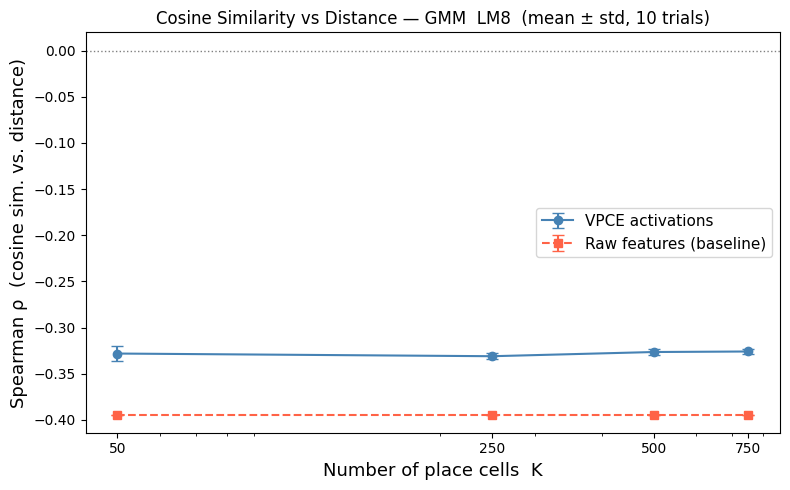

In [8]:
# ── Cosine similarity Spearman ρ ──────────────────────────────────────────────
cos_sub = stats_df[stats_df['metric'] == 'cos']

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    cos_sub['K'], cos_sub['vpce_mean_rho'], yerr=cos_sub['vpce_sd'],
    marker='o', capsize=4, label='VPCE activations', color='steelblue',
)
ax.errorbar(
    cos_sub['K'], cos_sub['raw_mean_rho'], yerr=cos_sub['raw_sd'],
    marker='s', capsize=4, linestyle='--', label='Raw features (baseline)', color='tomato',
)
ax.axhline(0, color='grey', linestyle=':', linewidth=1)
ax.set_xlabel('Number of place cells  K', fontsize=13)
ax.set_ylabel('Spearman ρ  (cosine sim. vs. distance)', fontsize=13)
ax.set_title(f'Cosine Similarity vs Distance — {METHOD.upper()}  LM8  (mean ± std, {N_TRIALS} trials)', fontsize=12)
ax.set_xscale('log')
ax.set_xticks(K_VALUES)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(fontsize=11)
plt.tight_layout()
savefig('exp2_spearman_cosine.png')
plt.show()

Saved → analysis/experiment_2_representational_geometry/figures/exp2_spearman_jsd.png


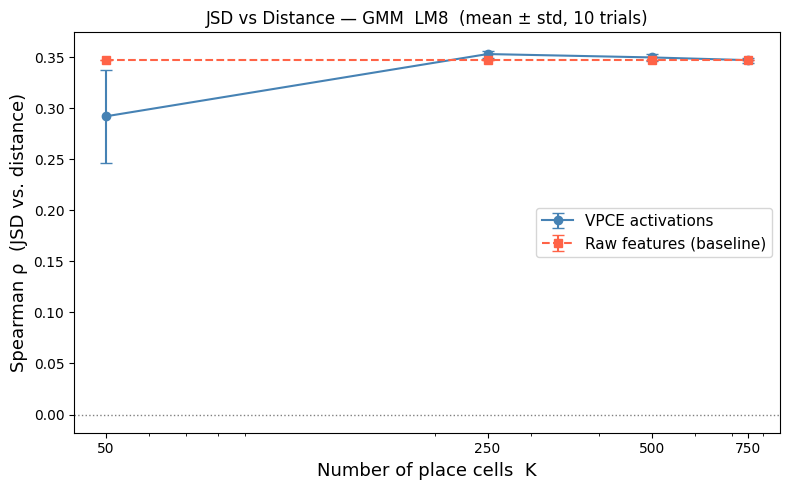

In [9]:
# ── JSD Spearman ρ ────────────────────────────────────────────────────────────
jsd_sub = stats_df[stats_df['metric'] == 'jsd']

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    jsd_sub['K'], jsd_sub['vpce_mean_rho'], yerr=jsd_sub['vpce_sd'],
    marker='o', capsize=4, label='VPCE activations', color='steelblue',
)
ax.errorbar(
    jsd_sub['K'], jsd_sub['raw_mean_rho'], yerr=jsd_sub['raw_sd'],
    marker='s', capsize=4, linestyle='--', label='Raw features (baseline)', color='tomato',
)
ax.axhline(0, color='grey', linestyle=':', linewidth=1)
ax.set_xlabel('Number of place cells  K', fontsize=13)
ax.set_ylabel('Spearman ρ  (JSD vs. distance)', fontsize=13)
ax.set_title(f'JSD vs Distance — {METHOD.upper()}  LM8  (mean ± std, {N_TRIALS} trials)', fontsize=12)
ax.set_xscale('log')
ax.set_xticks(K_VALUES)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(fontsize=11)
plt.tight_layout()
savefig('exp2_spearman_jsd.png')
plt.show()

---
## Summary Figure

Both metrics side-by-side in a 1 × 2 panel for the paper.

Saved → analysis/experiment_2_representational_geometry/figures/experiment_2_summary.png


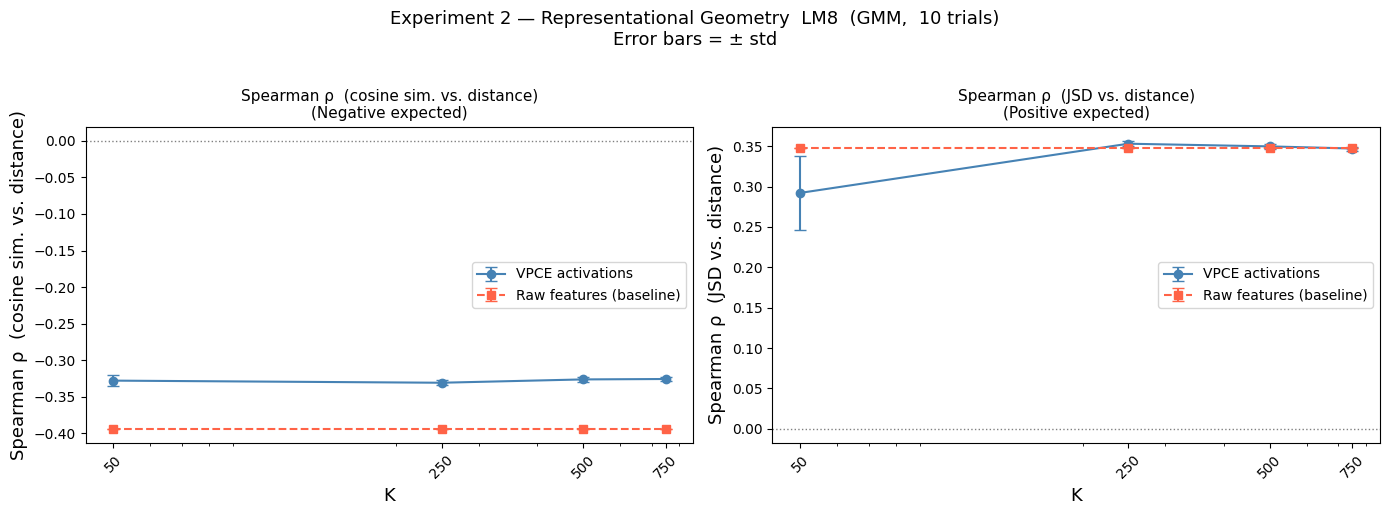

In [10]:
METRIC_SPECS = [
    ('cos', 'Spearman ρ  (cosine sim. vs. distance)', 'Negative expected'),
    ('jsd', 'Spearman ρ  (JSD vs. distance)',         'Positive expected'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metric, ylabel, note) in zip(axes, METRIC_SPECS):
    sub = stats_df[stats_df['metric'] == metric]
    ax.errorbar(
        sub['K'], sub['vpce_mean_rho'], yerr=sub['vpce_sd'],
        marker='o', markersize=6, capsize=4,
        label='VPCE activations', color='steelblue',
    )
    ax.errorbar(
        sub['K'], sub['raw_mean_rho'], yerr=sub['raw_sd'],
        marker='s', markersize=6, capsize=4, linestyle='--',
        label='Raw features (baseline)', color='tomato',
    )
    ax.axhline(0, color='grey', linestyle=':', linewidth=1)
    ax.set_xlabel('K', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(f'{ylabel}\n({note})', fontsize=11)
    ax.set_xscale('log')
    ax.set_xticks(K_VALUES)
    ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
    ax.tick_params(axis='x', labelrotation=45)
    ax.legend(fontsize=10)

fig.suptitle(
    f'Experiment 2 — Representational Geometry  LM8  ({METHOD.upper()},  {N_TRIALS} trials)\n'
    f'Error bars = ± std',
    fontsize=13, y=1.02,
)
plt.tight_layout()
savefig('experiment_2_summary.png')
plt.show()